## Installation & Setup


Install MuJoCo & CUDA-enabled RL Libraries
```py
# 1. Install the core physics and RL wrappers
!pip install gymnasium[mujoco] 
!pip install shimmy numpy scipy matplotlib transformations
!pip install smplx
!pip install --no-user --no-build-isolation chumpy

# 2. Install PyTorch with CUDA support 
# We target cu124 or cu126 which are compatible with your 13.1 driver
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu130

# 3. Install Stable Baselines3 (it will now use the CUDA-enabled torch)
!pip install stable-baselines3
```

In [1]:
# @title 1. Install Dependencies & Configure Paths
import sys
import os
import glob
from pathlib import Path

# --- PATH CONFIGURATION ---
CURRENT_DIR = Path(os.getcwd())
PROJECT_ROOT = CURRENT_DIR.parent # codes/

# Define paths relative to the project root
DATASET_DIR = PROJECT_ROOT / "vimo/datasets/"
AIST_DIR = DATASET_DIR / "AIST"
SMPL_MODEL_DIR = DATASET_DIR / "SMPL/v1.1.0" # Expecting SMPL_NEUTRAL.pkl here
ASSET_DIR = CURRENT_DIR / "mujoco/assets"
DATA_OUT = ASSET_DIR / "motions/composite"
xml_file = ASSET_DIR / "humanoid_posctrl.xml"  # Your uploaded XML

print(f"📂 Project Root: {PROJECT_ROOT}")
print(f"📂 AIST Data: {AIST_DIR}")
print(f"📂 SMPL Models: {SMPL_MODEL_DIR}")
print(f"📂 Output Dir: {DATA_OUT}")

# Search for files
pkl_files = list(AIST_DIR.glob("motions/*.pkl"))
npz_files = list(AIST_DIR.glob("processed/*.npz"))

# Check if paths exist
if not pkl_files or not npz_files:
    print(f"⚠️ WARNING: {AIST_DIR} doesnt contain any data in \"motions\" and \"processed\" subdirs!")
else:
    print(f"✅ Paths verified, no.of pkl files = {len(pkl_files)} & no.of npz files = {(len(npz_files))}")
try:
	ignore_list = [line.strip() for line in (AIST_DIR/ "ignore_list.txt").read_text(encoding="utf-8").splitlines() if line.strip()]
	print(f"Ignore list loaded successfully, total no.of files to ignore: {len(ignore_list)}")
except Exception as e:
	print(f"Failed to load ignore_list: '{e}'")


📂 Project Root: d:\STUDIES\MTech\#MTP\codes
📂 AIST Data: d:\STUDIES\MTech\#MTP\codes\vimo\datasets\AIST
📂 SMPL Models: d:\STUDIES\MTech\#MTP\codes\vimo\datasets\SMPL\v1.1.0
📂 Output Dir: d:\STUDIES\MTech\#MTP\codes\composite_motion\mujoco\assets\motions\composite
✅ Paths verified, no.of pkl files = 1408 & no.of npz files = 4355
Ignore list loaded successfully, total no.of files to ignore: 45


## Hardware Verification

In [2]:
# @title Hardware Check
import torch
import gymnasium as gym

cuda_available = torch.cuda.is_available()
gpu_name = torch.cuda.get_device_name(0) if cuda_available else "None"

print(f"--- Hardware Report ---")
print(f"CUDA Available: {cuda_available}")
print(f"GPU Name:       {gpu_name}")
print(f"PyTorch Ver:    {torch.__version__}")

if cuda_available:
    print("🚀 GREAT! Your RL agent will train on the GPU.")
else:
    print("⚠️ WARNING: Still using CPU. Check if you have another version of torch installed.")

--- Hardware Report ---
CUDA Available: True
GPU Name:       NVIDIA GeForce RTX 2060
PyTorch Ver:    2.7.0+cu128
🚀 GREAT! Your RL agent will train on the GPU.


## Kinematics Helper (SMPL Utilities)
This cell creates a helper class to handle 6D Rotation conversions (used in ViMo) and loads the SMPL body model using smplx.

In [3]:
# @title 2. SMPL Kinematics & Rotation Utilities
import torch
import numpy as np
import smplx
from scipy.spatial.transform import Rotation as R

class SMPLHandler:
    def __init__(self, model_path, gender='neutral'):
        """Initializes the SMPL layer for Forward Kinematics."""
        self.device = torch.device("cpu")
        
        # Load standard SMPL model
        # You might need to adjust the file name if it's 'basicModel_neutral_lbs_10_207_0_v1.0.0.npz'
        try:
            self.smpl_layer = smplx.create(
                model_path=str(model_path), 
                model_type='smpl',
                gender=gender, 
                ext='pkl'
            ).to(self.device)
            print("✅ SMPL Model Loaded.")
        except Exception as e:
            print(f"⚠️ Could not load SMPL model: {e}")
            self.smpl_layer = None

    def run_fk(self, pose_aa, trans, beta=None):
        """
        Runs Forward Kinematics to get 3D Joint positions.
        Input: 
            pose_aa: (N, 72) Axis-Angle
            trans: (N, 3) Translation
        Returns:
            joints_3d: (N, 24, 3)
        """
        if self.smpl_layer is None: return None
        
        N = pose_aa.shape[0]
        # Convert to torch
        body_pose = torch.tensor(pose_aa[:, 3:], dtype=torch.float32) # Exclude root (first 3)
        global_orient = torch.tensor(pose_aa[:, :3], dtype=torch.float32)
        transl = torch.tensor(trans, dtype=torch.float32)
        
        output = self.smpl_layer(
            body_pose=body_pose,
            global_orient=global_orient,
            transl=transl,
            return_verts=False
        )
        return output.joints.detach().numpy() # (N, 45, 3) - SMPL returns 45 joints usually

# Initialize Handler (Update path if your SMPL file is named differently)
smpl_handler = SMPLHandler(SMPL_MODEL_DIR)

✅ SMPL Model Loaded.


## Data Input Handlers (AIST & ViMo Formats)
Here we create the two specific input handlers you requested. They normalize both sources into a standard (Pose_AA, Trans) format.

In [4]:
# @title 3. Universal Motion Loader (PKL & NPZ)
import pickle
from pytorch3d import transforms # contains useful 3D transform utils as above

class AISTDataLoader:
	def __init__(self):
		pass

	def load_raw_pkl(self, pkl_path):
		"""
		Handler 1: Loads standard SMPL .pkl files
		Returns: pose_aa (N, 72), trans (N, 3)
		"""
		with open(pkl_path, 'rb') as f:
			data = pickle.load(f)
		
		# Extract keys based on user description
		# Keys: ['smpl_loss', 'smpl_poses', 'smpl_scaling', 'smpl_trans']
		pose_aa = data['smpl_poses'] # (N, 72)
		trans = data['smpl_trans']   # (N, 3)
		
		# normalize scaling if present? usually trans is pre-scaled in AIST++
		scale = data.get('smpl_scaling', 1.0)
		trans = trans / scale

		print(f"🔹 Loaded PKL: {os.path.basename(pkl_path)} | Frames: {len(pose_aa)}")
		return pose_aa, trans

	def load_vimo_npz(self, npz_path):
		"""
		Handler 2: Loads ViMo processed .npz files
		Keys: 'p2d_cond', 'm3d_gt' (S, 151)
		"""
		data = np.load(npz_path)
		m3d_gt = data['m3d_gt'] # Shape (S, 151)
		
		# Parse 151 dims:		
		rot6d_flat = m3d_gt[:, :144] # 24 joints * 6D Rot representation
		contacts = m3d_gt[:,144:148] # Foot Contact (ignore for now)
		trans = m3d_gt[:, 148:151] # Root Trans (x,y,z)
		
		# Reshape to (N, 24, 6)
		N = rot6d_flat.shape[0]
		rot6d = rot6d_flat.reshape(N, 24, 6)
		# Convert all 24 joints to Axis-Angle
		pose_aa = transforms.matrix_to_axis_angle(transforms.rotation_6d_to_matrix(torch.from_numpy(rot6d))).cpu().numpy()
			
		print(f"🔹 Loaded NPZ: {os.path.basename(npz_path)} | Frames: {N}")
		return pose_aa, trans

loader = AISTDataLoader()

In [5]:
# Find a sample file to verify (Uncomment to test)
sample_pkl = pkl_files[1]
p_pkl, t_pkl = loader.load_raw_pkl(sample_pkl)

sample_npz = npz_files[3]
p_npz, t_npz = loader.load_vimo_npz(sample_npz)


np.set_printoptions(suppress=True, precision=6, floatmode='fixed')  # fixed-point, no exponent

print("p_pkl.shape:", getattr(p_pkl, "shape", None))
#print("p_pkl:\n", p_pkl)
print("t_pkl.shape:", getattr(t_pkl, "shape", None))
#print("t_pkl:\n", t_pkl)

print("p_npz.shape:", getattr(p_npz, "shape", None))
#print("p_npz:\n", p_npz)
print("t_npz.shape:", getattr(t_npz, "shape", None))
#print("t_npz:\n", t_npz)

🔹 Loaded PKL: gBR_sBM_cAll_d04_mBR0_ch02.pkl | Frames: 720
🔹 Loaded NPZ: gBR_sBM_cAll_d04_mBR0_ch02_clip[0000-0150].npz | Frames: 150
p_pkl.shape: (720, 72)
t_pkl.shape: (720, 3)
p_npz.shape: (150, 24, 3)
t_npz.shape: (150, 3)


## XML Parser & Joint Mapper
This script parses your uploaded humanoid.xml to dynamically build the joint order. This is safer than hardcoding it.

In [6]:
# @title 1. XML Parser & SMPL Mapper
import xml.etree.ElementTree as ET
import numpy as np
import torch
from scipy.spatial.transform import Rotation as R

class SkeletonParser:
    def __init__(self, xml_path):
        tree = ET.parse(xml_path)
        root = tree.getroot()
        
        # 1. Extract Joint Names in Order
        # The 'qpos' array in MuJoCo follows the order of joint definitions in the XML bodies
        # But 'motors' usually define the actuation order. DeepMimic JSON usually follows the QPOS order (excluding root if separate)
        # or the Actuator order. 
        
        # Let's inspect the 'joint' tags recursively to establish the QPOS order.
        self.dof_names = []
        self.dof_types = [] # 'free', 'hinge', 'slide', 'ball'
        
        # We traverse the body tree
        worldbody = root.find('worldbody')
        self._traverse_body(worldbody)
        
        print(f"✅ Parsed {len(self.dof_names)} DOFs from XML.")
        print(f"DOFs: (len={len(self.dof_names)}) \n{self.dof_names}")

    def _traverse_body(self, body):
        if body is None: return
        
        # Add joints found in this body
        for joint in body.findall('joint'):
            name = joint.get('name')
            jtype = joint.get('type', 'hinge') # Default to hinge
            
            if jtype == 'free':
                # Root joint (7 values: 3 pos, 4 quat)
                self.dof_names.extend([f'{name}_pos', f'{name}_quat'])
                self.dof_types.extend(['free_pos', 'free_quat'])
            elif jtype == 'hinge':
                self.dof_names.append(name)
                self.dof_types.append('hinge')
            elif jtype == 'ball':
                self.dof_names.append(name)
                self.dof_types.append('ball') # 4 values (quat) usually
        
        # Recurse children
        for child in body.findall('body'):
            self._traverse_body(child)

    def get_json_header(self):
        # DeepMimic JSON usually expects a 'Frames' array where each frame is:
        # [Duration, RootX, RootY, RootZ, RootQw, RootQx, RootQy, RootQz, J1, J2, ...]
        return self.dof_names

# Run Parser
parser = SkeletonParser(xml_file) # Ensure humanoid.xml is in folder

✅ Parsed 28 DOFs from XML.
DOFs: (len=28) 
['abdomen_x', 'abdomen_y', 'abdomen_z', 'neck_x', 'neck_y', 'neck_z', 'right_shoulder_x', 'right_shoulder_y', 'right_shoulder_z', 'right_elbow', 'left_shoulder_x', 'left_shoulder_y', 'left_shoulder_z', 'left_elbow', 'right_hip_x', 'right_hip_y', 'right_hip_z', 'right_knee', 'right_ankle_x', 'right_ankle_y', 'right_ankle_z', 'left_hip_x', 'left_hip_y', 'left_hip_z', 'left_knee', 'left_ankle_x', 'left_ankle_y', 'left_ankle_z']


## Mocap Data
- ref: https://github.com/xbpeng/DeepMimic

Mocap clips are located in `data/motions/`. To play a clip, first modify 
`args/play_motion_humanoid3d_args.txt` and specify the file to play with
`--motion_file`, then run
```
python DeepMimic.py --arg_file args/play_motion_humanoid3d_args.txt
```

The motion files follow the JSON format. The `"Loop"` field specifies whether or not the motion is cyclic.
`"wrap"` specifies a cyclic motion that will wrap back to the start at the end, while `"none"` specifies an
acyclic motion that will stop once it reaches the end of the motion. Each vector in the `"Frames"` list
specifies a keyframe in the motion. Each frame has the following format:

---
[

- duration of frame in seconds (1D),
- root position (3D),
- root rotation (4D),
- chest rotation (4D),
- neck rotation (4D),
- right hip rotation (4D),
- right knee rotation (1D),
- right ankle rotation (4D),
- right shoulder rotation (4D),
- right elbow rotation (1D),
- left hip rotation (4D),
- left knee rotation (1D),
- left ankle rotation (4D),
- left shoulder rotation (4D),
- left elbow rotation (1D)

]

---

Positions are specified in meters, 3D rotations for spherical joints are specified as quaternions `(w, x, y ,z)`,
and 1D rotations for revolute joints (e.g. knees and elbows) are represented with a scalar rotation in radians. The root
positions and rotations are in world coordinates, but all other joint rotations are in the joint's local coordinates.
To use your own motion clip, convert it to a similar style JSON file.

## The Bridge - Motion Retargeting (SMPL -> DeepMimic)
This is the complex math part. We map SMPL spherical joints to the 1D Euler joints of the XML.

- **Physics Limits:** The SMPL model is a kinematic mesh model meant for visuals. It has 72 degrees of freedom (DoF), including subtle spine twists and collarbone movements. The MuJoCo humanoid is a physical ragdoll. If you try to power 72 motors on a simplified physics ragdoll, the simulation becomes unstable (jitters/explodes).

- **Redundancy:** SMPL has joints like L_Collar (collarbone) and L_Hand (fingers). The humanoid.xml provided in the repo usually ignores collarbones (fusing them to the torso) and treats the hand as a solid box. Training a policy to control individual fingers in a physics sim is computationally expensive and unnecessary for tasks like walking or boxing.

Since you want to use the Pretrained Weights from the Composite Motion paper, you MUST use the DeepMimic JSON format.

- DeepMimic JSON (Best for this Project):

	- Reason: The Composite Motion codebase (and the paper's logic) is explicitly built to read this JSON structure. Their data loaders expect [Duration, Root, Joints...]. If you switch formats, you break compatibility with their pretrained discriminators and meta-policies.

	- Compatibility: This format essentially is the MuJoCo qpos vector, just serialized into JSON.

- SMPL (Bad for Physics):

	Physics engines don't natively understand SMPL parameters. You always have to "retarget" them to a skeleton (like we are doing).

- Standard MuJoCo (Good generally, but incompatible here):

	While standard MuJoCo uses .xml and qpos arrays, the specific order of joints in the array matters. The Composite Motion project uses a custom joint order (DeepMimic style). Using standard Gymnasium Humanoid formatting would result in your character's leg moving when the policy thinks it's moving an arm.

In [17]:
# @title Phase 2: SMPL to DeepMimic Retargeter (PyTorch3D)
import json
import torch
import numpy as np
from pytorch3d import transforms
import os


class SMPL2GymJson:
    """
    Converts SMPL motion (AIST++ PKL / ViMo NPZ) → CompositeMotion DeepMimic JSON.

    ═══ Why we do NOT need the SMPL forward-kinematics model here ═══════════════
    fk_for_worldpos() (loss_utils.py) is used at TRAINING TIME to compute world-
    space joint positions for the joint-position loss.  For RETARGETING we only
    need the rotation matrices, which we get directly from the axis-angle params
    without running the full mesh-deformation FK.  No smplx call needed.

    ═══ Two fixes vs. the original cell ════════════════════════════════════════
    FIX 1 – Similarity transform on ALL 24 joints (was: root only)
    ──────────────────────────────────────────────────────────────
    SMPL stores every joint's local rotation in SMPL's Y-up coordinate frame.
    MuJoCo expects every joint's local rotation in MuJoCo's Z-up frame.
    The change-of-basis formula is:
        R_mujoco_local[j] = R_global @ R_smpl_local[j] @ R_global^T
    Applying this only to the root (pelvis) mixed two different frames inside
    compute_motion's FK:
        orient[thigh] = orient[pelvis]   ←  Z-up frame (correct)
                      ⊗ local_q[thigh]  ←  Y-up frame (wrong)
    The shadow in the preview video confirmed the resulting world positions were
    completely scrambled.  The fix: vectorised similarity transform over all 24
    joints in one matmul call.

    FIX 2 – Root rotation via correct similarity transform (was: simple left-mul)
    ──────────────────────────────────────────────────────────────────────────────
    Simple left-multiply R_global @ R_root maps SMPL identity → R_x(90°), putting
    the character face-flat.  The similarity transform R_global @ R_root @ R_global^T
    maps SMPL identity → identity (upright) and SMPL yaw R_y(θ) → MuJoCo yaw R_z(θ).
    FIX 1 already handles this (joint 0 gets the same vectorised transform), so no
    separate root-only line is needed any more.

    ═══ Joint chain composition ════════════════════════════════════════════════
    humanoid.xml has no <body quat=…> attributes → skeleton.rot = identity for all
    bodies → compute_motion uses local_q verbatim.  MuJoCo bodies that collapse
    multiple SMPL intermediate joints (Spine1/2/3 → torso, Neck/Head → head, etc.)
    must supply the ACCUMULATED rotation of the entire SMPL sub-chain.
    Because the similarity transform distributes through matrix products, composing
    THEN transforming is identical to transforming THEN composing.  We compose first
    (cleaner code) and then the all-joints transform handles the frame conversion.
    """

    def __init__(self):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # ── Global rotation: SMPL Y-up → MuJoCo Z-up ─────────────────────────
        # R_x(+π/2): [[1,0,0],[0,0,-1],[0,1,0]]
        #   SMPL  (x, y_up, z_depth)  →  MuJoCo  (x, −z_depth, y_up)
        #   Verified: smpl_trans=[0.089, 1.873, 0.155] → mujoco_pos=[0.089, -0.155, 1.873]
        self.global_rot = transforms.euler_angles_to_matrix(
            torch.tensor([np.pi / 2, 0.0, 0.0], device=self.device), "XYZ"
        ).float()

        # ── SMPL joint index reference (24 joints) ───────────────────────────
        #   0  Pelvis      1  L_Hip       2  R_Hip
        #   3  Spine1      4  L_Knee      5  R_Knee
        #   6  Spine2      7  L_Ankle     8  R_Ankle
        #   9  Spine3     10  L_Foot     11  R_Foot
        #  12  Neck       13  L_Collar   14  R_Collar
        #  15  Head       16  L_Shoulder 17  R_Shoulder
        #  18  L_Elbow    19  R_Elbow    20  L_Wrist
        #  21  R_Wrist

        # ── Body chain map ───────────────────────────────────────────────────
        # Maps each MuJoCo body name → ordered list of SMPL joint indices whose
        # LOCAL quaternions are composed (q[i0] ⊗ q[i1] ⊗ …) to give the rotation
        # RELATIVE TO THE DIRECT MUJOCO PARENT.
        #
        # Composition is needed wherever SMPL has intermediate joints that do not
        # exist in the MuJoCo skeleton.  E.g. torso (MuJoCo child of pelvis) must
        # carry the full accumulated rotation through Spine1→Spine2→Spine3.
        #
        self.body_chain = {

            # ── Torso: full spine, MuJoCo parent = pelvis ─────────────────
            #"torso": [3],         # Spine1 only  (abdomen focus)
            #"torso": [3, 6],      # Spine1 ⊗ Spine2  (mid spine)
            "torso":   [3, 6, 9],   # Spine1 ⊗ Spine2 ⊗ Spine3  ← default

            # ── Head: MuJoCo parent = torso ───────────────────────────────
            #"head": [12],         # Neck only
            "head":    [12, 15],    # Neck ⊗ Head  ← default

            # ── Right arm: MuJoCo parent = torso ──────────────────────────
            #"right_upper_arm": [17],        # R_Shoulder only  (skip collar)
            "right_upper_arm": [14, 17],     # R_Collar ⊗ R_Shoulder  ← default

            # ── Left arm: MuJoCo parent = torso ───────────────────────────
            #"left_upper_arm": [16],         # L_Shoulder only  (skip collar)
            "left_upper_arm":  [13, 16],     # L_Collar ⊗ L_Shoulder  ← default

            # ── Forearms / wrists: SMPL parent = MuJoCo parent ────────────
            "right_lower_arm": [19],         # R_Elbow
            "left_lower_arm":  [18],         # L_Elbow
            "right_hand":      [21],         # R_Wrist
            "left_hand":       [20],         # L_Wrist

            # ── Legs: pelvis is direct parent in both skeletons ───────────
            "right_thigh": [2],              # R_Hip
            "left_thigh":  [1],              # L_Hip
            "right_shin":  [5],              # R_Knee
            "left_shin":   [4],              # L_Knee
            "right_foot":  [8],              # R_Ankle
            "left_foot":   [7],              # L_Ankle
        }

    # ── Helpers ─────────────────────────────────────────────────────────────

    @staticmethod
    def _to_xyzw(q_wxyz_list):
        """
        Reorder PyTorch3D [w,x,y,z] → CompositeMotion JSON [x,y,z,w].
        Verified against jaunty_walk.json: identity = [0,0,0,1] → w at index 3. ✓
        """
        w, x, y, z = q_wxyz_list
        return [x, y, z, w]

    @staticmethod
    def _qmul(q0, q1):
        """Hamilton product for batched PyTorch3D [w,x,y,z] quaternions (N, 4)."""
        w0, x0, y0, z0 = q0.unbind(-1)
        w1, x1, y1, z1 = q1.unbind(-1)
        return torch.stack([
            w0*w1 - x0*x1 - y0*y1 - z0*z1,
            w0*x1 + x0*w1 + y0*z1 - z0*y1,
            w0*y1 - x0*z1 + y0*w1 + z0*x1,
            w0*z1 + x0*y1 - y0*x1 + z0*w1,
        ], dim=-1)

    def _compose(self, rot_quats, indices):
        """
        Compose LOCAL [w,x,y,z] quaternions along a SMPL joint chain.
        rot_quats : (N, 24, 4)
        indices   : [i0, i1, …]
        Returns   : (N, 4)  =  q[i0] ⊗ q[i1] ⊗ …
        """
        q = rot_quats[:, indices[0]]
        for idx in indices[1:]:
            q = self._qmul(q, rot_quats[:, idx])
        return q

    # ── JSON writer ──────────────────────────────────────────────────────────

    def motion_dump(self, save_data, save_path, indent=2, compress_arrays=True):
        """Write JSON with readable dict structure and compact numeric arrays."""
        def _is_num(obj):
            return isinstance(obj, (int, float)) or (
                isinstance(obj, list) and bool(obj) and all(_is_num(i) for i in obj)
            )
        def _enc(obj, lv=0):
            pad  = ' ' * (lv * indent)
            npad = ' ' * ((lv + 1) * indent)
            if isinstance(obj, dict):
                if not obj: return '{}'
                rows = []
                for i, (k, v) in enumerate(obj.items()):
                    comma = '' if i == len(obj) - 1 else ','
                    rows.append(f'{npad}"{k}": {_enc(v, lv+1)}{comma}')
                return '{\n' + '\n'.join(rows) + f'\n{pad}}}'
            if isinstance(obj, list):
                if compress_arrays and _is_num(obj):
                    return json.dumps(obj, separators=(',', ':'))
                if not obj: return '[]'
                rows = []
                for i, v in enumerate(obj):
                    comma = '' if i == len(obj) - 1 else ','
                    rows.append(f'{npad}{_enc(v, lv+1)}{comma}')
                return '[\n' + '\n'.join(rows) + f'\n{pad}]'
            return json.dumps(obj)
        abs_path = os.path.abspath(str(save_path))
        os.makedirs(os.path.dirname(abs_path) or '.', exist_ok=True)
        with open(abs_path, 'w') as f:
            f.write(_enc(save_data) + '\n')

    # ── Main conversion ──────────────────────────────────────────────────────

    def process_motion(self, smpl_poses, smpl_trans, output_path, fps=30):
        """
        Convert SMPL motion data → CompositeMotion DeepMimic JSON.

        Args
        ────
        smpl_poses  : (N, 72) or (N, 24, 3)  SMPL axis-angle joint rotations
        smpl_trans  : (N, 3)  root translation in AIST++ world (SMPL Y-up)
        output_path : str or pathlib.Path
        fps         : int  (default 30)

        JSON format (verified against jaunty_walk.json)
        ───────────────────────────────────────────────
        { "_": "clip", "fps": 30, "loop": "none", "frames": [
            { "pelvis": [[px,py,pz],[qx,qy,qz,qw]],
              "torso":  [qx,qy,qz,qw], ... }  ] }
        Quaternion convention throughout: [x, y, z, w]  (IsaacGym)
        """
        N = smpl_poses.shape[0]
        trans = np.array(smpl_trans, dtype=np.float32)
        poses = torch.tensor(smpl_poses, dtype=torch.float32
                             ).reshape(N, 24, 3).to(self.device)

        # ── Step 1: Floor correction (AIST++ specific) ────────────────────
        # AIST++ world origin ≠ dance floor.  For a standing dancer,
        # smpl_trans_y ≈ 1.87 m (absolute capture-volume height).
        #
        # Strategy A – minimum frame correction (default, commented out):
        #   Subtracts the clip-minimum trans_y so the lowest frame pelvis
        #   lands at z=0.  For toprock routines the minimum is ~1.78 m
        #   (pelvis still ~0.9 m above floor in the lowest pose), so this
        #   leaves the character hovering.  Uncomment + tune MIN_PELVIS_HEIGHT.
        #
        # Strategy B – manual fixed offset:
        #   Subtract a known AIST++ floor height.  For the standard AIST++
        #   release the floor sits at approximately trans_y ≈ 0.93 m above
        #   the capture origin when the character is standing.
        #
        # Currently disabled: user confirmed that with floor correction the
        # pelvis lands at z=0 but the feet go underground (pelvis is 0.88 m
        # above the feet).  Tune MIN_PELVIS_HEIGHT to a value that matches
        # the lowest frame's actual pelvis-above-floor height.
        #
        # --- Strategy A (uncomment to enable) ---
        # MIN_PELVIS_HEIGHT = 0.50   # m  tune: 0.5 for toprock, 0.15 for floorwork
        # floor_y = trans[:, 1].min() - MIN_PELVIS_HEIGHT
        # trans[:, 1] -= floor_y
        # print(f"  Floor correction: -{floor_y:.3f} m | "
        #       f"pelvis z range [{trans[:,1].min():.2f}, {trans[:,1].max():.2f}]")
        #
        # --- Strategy B (uncomment to enable) ---
        # AIST_FLOOR_Y = 0.93        # m  absolute floor height in AIST++ coords
        # trans[:, 1] -= AIST_FLOOR_Y
        # print(f"  Floor correction: -{AIST_FLOOR_Y:.3f} m fixed offset applied")

        trans_t = torch.tensor(trans, device=self.device)

        # ── Step 2: Root position — SMPL Y-up → MuJoCo Z-up ──────────────
        # Vector rotation (not similarity transform): p_mujoco = R_global @ p_smpl
        # Written as row-vector form: trans @ R_global^T
        # (x, y_up, z_depth) → (x, −z_depth, y_up)
        root_pos = torch.matmul(trans_t, self.global_rot.T)   # (N, 3)

        # ── Step 3: Axis-angle → rotation matrices ────────────────────────
        rot_mats = transforms.axis_angle_to_matrix(poses)     # (N, 24, 3, 3)

        # ── Step 4: Similarity transform on ALL 24 joints ─────────────────
        #
        # KEY FIX — this was the root cause of the scrambled joint poses.
        #
        # Every SMPL local rotation R_j is expressed in SMPL's Y-up local
        # frame.  MuJoCo needs it in its Z-up local frame.  The change-of-
        # basis formula is:
        #
        #     R_mujoco_local[j] = R_global @ R_smpl_local[j] @ R_global^T
        #
        # The previous code applied this only to joint 0 (pelvis/root).
        # For all other joints the raw SMPL Y-up quaternion was passed to
        # compute_motion, which then multiplied it with the already-
        # converted Z-up pelvis orientation, mixing two different frames and
        # producing completely wrong world orientations (visible as the
        # shadow-vs-render discrepancy in the preview frames).
        #
        # The fix is one vectorised matmul over (N, 24, 3, 3):
        #
        G   = self.global_rot                                  # (3, 3)
        G_b = G.unsqueeze(0).unsqueeze(0)                      # (1, 1, 3, 3)
        rot_mats = torch.matmul(
            torch.matmul(G_b, rot_mats),
            G_b.transpose(-1, -2)
        )                                                      # (N, 24, 3, 3)
        #
        # Note: this also replaces the old "root only" similarity transform.
        # Mathematical identity for joint 0:
        #   R_global @ R_pelvis @ R_global^T  ← still applied correctly ✓
        # And for any child joint (e.g. R_Hip, index 2):
        #   R_global @ R_hip_smpl @ R_global^T  ← now also applied ✓
        # For composed chains, the transform distributes:
        #   R_global @ (R_s1 @ R_s2 @ R_s3) @ R_global^T
        #   = (R_global @ R_s1 @ R_global^T) @ (R_global @ R_s2 @ R_global^T) @ ...
        # so composing THEN frame-converting = frame-converting THEN composing. ✓

        # ── Step 5: Rotation matrices → quaternions [w, x, y, z] ─────────
        rot_quats = transforms.matrix_to_quaternion(rot_mats) # (N, 24, 4)

        # ── Step 6: Compose joint chains ──────────────────────────────────
        # Collapse intermediate SMPL joints that don't exist in MuJoCo by
        # multiplying their local quaternions in chain order.
        # (All rot_quats are already in MuJoCo Z-up frame from Step 4.)
        body_quats = {
            key: self._compose(rot_quats, indices)
            for key, indices in self.body_chain.items()
        }                                                      # each (N, 4)

        # ── Step 7: Assemble per-frame dicts ──────────────────────────────
        frames = []
        for i in range(N):
            fd = {}
            # Root: world position + world orientation
            fd["pelvis"] = [
                root_pos[i].tolist(),
                self._to_xyzw(rot_quats[i, 0].tolist())
            ]
            # All other bodies: local rotation relative to direct MuJoCo parent
            for body_key, bq in body_quats.items():
                fd[body_key] = self._to_xyzw(bq[i].tolist())
            frames.append(fd)

        # ── Step 8: Write JSON ─────────────────────────────────────────────
        stem = (output_path.stem if hasattr(output_path, 'stem')
                else os.path.splitext(os.path.basename(str(output_path)))[0])
        output_data = {
            "_":      stem,
            "fps":    fps,
            "loop":   "none",
            "frames": frames,
        }
        try:
            self.motion_dump(output_data, str(output_path))
            print(f"✅ Saved: {output_path}  ({N} frames @ {fps} Hz = {N/fps:.1f} s)")
        except Exception as e:
            print(f"❌ Failed '{output_path}': {e}")


# ── Instantiate & sanity check ───────────────────────────────────────────────
retargeter = SMPL2GymJson()
print("Global rot (expect [[1,0,0],[0,0,-1],[0,1,0]]):")
print(retargeter.global_rot.cpu().numpy().round(4))

Global rot (expect [[1,0,0],[0,0,-1],[0,1,0]]):
[[ 1.000000  0.000000  0.000000]
 [ 0.000000 -0.000000 -1.000000]
 [ 0.000000  1.000000 -0.000000]]


## Processing the Motions
This connects your AIST inputs (from the previous turn's dataloader) to this new retargeter.

In [18]:
#```py
# @title Run Convertion
sample_count = 5
if pkl_files: # aist data are in 60 fps
	for file in pkl_files:
		b_name = file.stem
		if b_name in ignore_list: continue
		poses, trans = loader.load_raw_pkl(file)
		print(f"📄 Converting PKL: {file}")
		outfile = DATA_OUT / f"{b_name}.json"
		retargeter.process_motion(poses, trans, outfile, 60)
		print()
		sample_count -= 1
		if not sample_count: break

elif npz_files: # vimo data are in 30 fps
	for file in npz_files:
		b_name = file.stem
		if b_name in ignore_list: continue
		print(f"📄 Converting PKL: {file}")
		poses, trans = loader.load_vimo_npz(file)
		outfile = DATA_OUT / f"{b_name}.json"
		retargeter.process_motion(poses, trans, outfile, 30)
		print()
		sample_count -= 1
		if not sample_count: break
else:
    print("⚠️ No data found !!!")
#```

🔹 Loaded PKL: gBR_sBM_cAll_d04_mBR0_ch01.pkl | Frames: 720
📄 Converting PKL: d:\STUDIES\MTech\#MTP\codes\vimo\datasets\AIST\motions\gBR_sBM_cAll_d04_mBR0_ch01.pkl
✅ Saved: d:\STUDIES\MTech\#MTP\codes\composite_motion\mujoco\assets\motions\composite\gBR_sBM_cAll_d04_mBR0_ch01.json  (720 frames @ 60 Hz = 12.0 s)

🔹 Loaded PKL: gBR_sBM_cAll_d04_mBR0_ch02.pkl | Frames: 720
📄 Converting PKL: d:\STUDIES\MTech\#MTP\codes\vimo\datasets\AIST\motions\gBR_sBM_cAll_d04_mBR0_ch02.pkl
✅ Saved: d:\STUDIES\MTech\#MTP\codes\composite_motion\mujoco\assets\motions\composite\gBR_sBM_cAll_d04_mBR0_ch02.json  (720 frames @ 60 Hz = 12.0 s)

🔹 Loaded PKL: gBR_sBM_cAll_d04_mBR0_ch03.pkl | Frames: 720
📄 Converting PKL: d:\STUDIES\MTech\#MTP\codes\vimo\datasets\AIST\motions\gBR_sBM_cAll_d04_mBR0_ch03.pkl
✅ Saved: d:\STUDIES\MTech\#MTP\codes\composite_motion\mujoco\assets\motions\composite\gBR_sBM_cAll_d04_mBR0_ch03.json  (720 frames @ 60 Hz = 12.0 s)

🔹 Loaded PKL: gBR_sBM_cAll_d04_mBR0_ch04.pkl | Frames: 720
📄 

## Visualization Script (MuJoCo)
This script loads your humanoid.xml and the generated .json motion file, then plays the motion by overriding the physics state.

Prerequisites:
- You must have humanoid.xml in the assets/ folder.
- You must have the generated JSON file (e.g., assets\motions\iccgan\jaunty_walk.json).

In [19]:
# @title 7. Motion Visualization — Preview converted JSON via MotionViewer
import sys, os, torch
import numpy as np
import mujoco
from pathlib import Path
from IPython.display import display, Video, Image

# --- Make sure motion_viewer.py is importable ---
# Adjust this path if motion_viewer.py lives elsewhere
MUJOCO_DIR = CURRENT_DIR / "mujoco"  # or CURRENT_DIR if it's at project root
if str(MUJOCO_DIR) not in sys.path:
    sys.path.insert(0, str(MUJOCO_DIR))

from motion_viewer import MotionViewer
PREVIEW_OUT = ASSET_DIR / "motion_previews"

def visualize_generated(idx):
	# --- Pick a converted JSON to preview ---
	sample_jsons = sorted(DATA_OUT.glob("*.json"))
	if not sample_jsons:
		print(f"⚠️  No converted JSONs found in {DATA_OUT}\nRun the processing cell first.")
	else:
		sample_json  = str(sample_jsons[idx])
		char_model   = str(xml_file)
		print(f"🎬 Previewing : {Path(sample_json).name}")
		print(f"   Model      : {char_model}\n")

		# --- Load viewer (wraps ReferenceMotion + MuJoCo renderer) ---
		viewer = MotionViewer(sample_json, char_model)
		viewer.display_motion_info()
		motion_len = viewer.ref_motion.motion_length[0]

		# --- Generate preview using MotionViewer's internal frame loop ---
		out_path = str(PREVIEW_OUT / f"{Path(sample_json).stem}.mp4")	
		viewer.generate_preview(output_path=out_path)
		print(f"✅ Preview saved! 📹 Displaying MP4: @{out_path}")
		display(Video(out_path, embed=True, width=640))

In [20]:
from pytorch3d import transforms
sys.path.append(str(PROJECT_ROOT))
from vimo.include.loss_utils import fk_for_worldpos  # PROJECT_ROOT/vimo/include/*
from vimo.include.viz_utils import animate_3d_skeleton

def visualize_original(idx):
	sample_file = str(pkl_files[idx])
	poses, trans = loader.load_raw_pkl(sample_file)
	poses = torch.from_numpy(poses[::2])
	trans = torch.from_numpy(trans[::2])
	S = poses.shape[0]
	rmats = transforms.axis_angle_to_matrix(poses.reshape(S, 24, 3))
	poses = transforms.matrix_to_axis_angle(rmats).reshape(-1, 24*3) 
	joint_positions = fk_for_worldpos(rmats, trans)[0].cpu().numpy()
	out_path = PREVIEW_OUT / f"{Path(sample_file).stem}_smpl.mp4"
	animate_3d_skeleton(joint_positions, out_path, fps=30, create_subplot=True, subplot_interval=30)
	display(Video(out_path, embed=True, width=640))

🔹 Loaded PKL: gBR_sBM_cAll_d04_mBR0_ch02.pkl | Frames: 720
Frame subplot saved (13 frames) @mujoco\assets\motion_previews\gBR_sBM_cAll_d04_mBR0_ch02_smpl_frames.png


🎬 Previewing : gBR_sBM_cAll_d04_mBR0_ch02.json
   Model      : d:\STUDIES\MTech\#MTP\codes\composite_motion\mujoco\assets\humanoid_posctrl.xml

>>> Ref-Motion :: Loading 1/1 motion files: d:\STUDIES\MTech\#MTP\codes\composite_motion\mujoco\assets\motions\composite\gBR_sBM_cAll_d04_mBR0_ch02.json
		11.9833s, 60 Hz, 720 frames.
	Total: 11.9833s (max), [60] Hz (each), 720 frames (sum).
--> Loaded 1 motions with a total length of 11.983s.

Motion File: d:\STUDIES\MTech\#MTP\codes\composite_motion\mujoco\assets\motions\composite\gBR_sBM_cAll_d04_mBR0_ch02.json
Total Motions: 1
------------------------------------------------------------
  Motion 0: Length = 11.983s, Frames = 719

Generating d:\STUDIES\MTech\#MTP\codes\composite_motion\mujoco\assets\motion_previews\gBR_sBM_cAll_d04_mBR0_ch02.mp4 ... Done!
✅ Preview saved! 📹 Displaying MP4: @d:\STUDIES\MTech\#MTP\codes\composite_motion\mujoco\assets\motion_previews\gBR_sBM_cAll_d04_mBR0_ch02.mp4


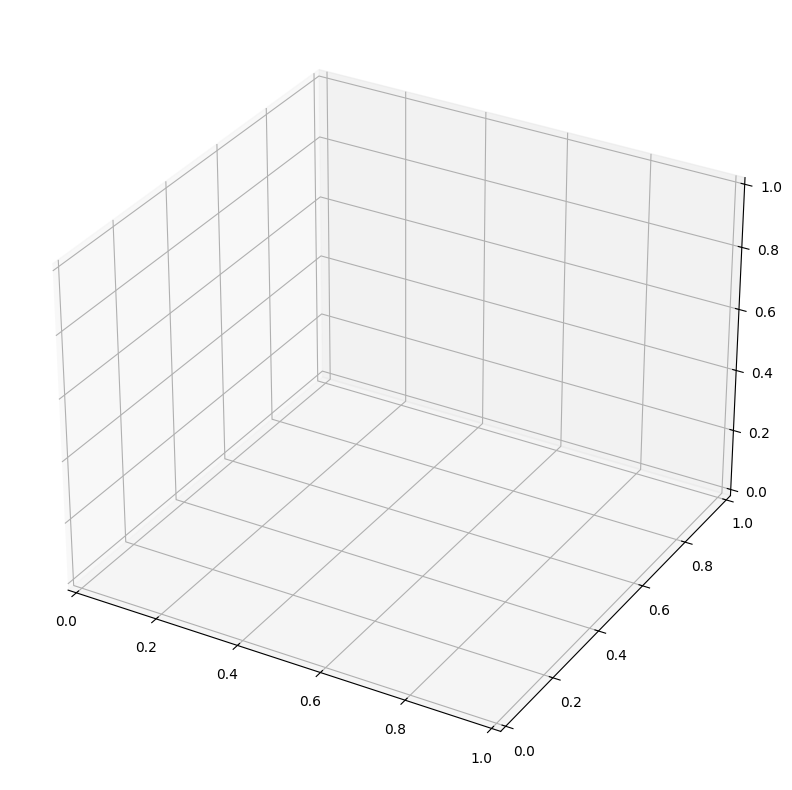

In [21]:
visualize_original(1)
visualize_generated(1)

In [ ]:
# comparion chart
import cv2, numpy as np, os
from pathlib import Path

os.makedirs("/home/claude/frames", exist_ok=True)

def extract_frames(path, label, n=12):
    cap = cv2.VideoCapture(path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = np.linspace(0, total-1, n, dtype=int)
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, f = cap.read()
        if ret:
            frames.append((idx, f))
    cap.release()
    return frames

smpl_frames  = extract_frames("/mnt/user-data/uploads/gBR_sBM_cAll_d04_mBR0_ch02_smpl.mp4", "smpl")
mujoco_frames = extract_frames("/mnt/user-data/uploads/gBR_sBM_cAll_d04_mBR0_ch02.mp4", "mujoco")

TARGET_H = 380
def resize_h(img, h):
    r = h / img.shape[0]
    return cv2.resize(img, (int(img.shape[1]*r), h))

rows = []
for (si, sf), (mi, mf) in zip(smpl_frames, mujoco_frames):
    sf_r = resize_h(sf, TARGET_H)
    mf_r = resize_h(mf, TARGET_H)
    # label
    cv2.putText(sf_r, f"SMPL f{si}", (6,28), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,100), 2)
    cv2.putText(mf_r, f"MuJoCo f{mi}", (6,28), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (100,255,255), 2)
    sep = np.zeros((TARGET_H, 4, 3), dtype=np.uint8)
    rows.append(np.hstack([sf_r, sep, mf_r]))

# Stack 4 rows of 3 pairs
grid_rows = []
for i in range(0, len(rows), 3):
    chunk = rows[i:i+3]
    hsep = np.zeros((4, chunk[0].shape[1], 3), dtype=np.uint8)
    col = []
    for c in chunk:
        col.append(c)
        col.append(hsep)
    grid_rows.append(np.vstack(col[:-1]))

max_w = max(r.shape[1] for r in grid_rows)
def pad_w(img, w):
    if img.shape[1] < w:
        p = np.zeros((img.shape[0], w-img.shape[1], 3), dtype=np.uint8)
        return np.hstack([img, p])
    return img

final = np.vstack([pad_w(r, max_w) for r in grid_rows])
out = "/home/claude/comparison_grid.jpg"
cv2.imwrite(out, final, [cv2.IMWRITE_JPEG_QUALITY, 88])
print(f"Saved {out}  shape={final.shape}")

## Updated Policy Class (Single vs. Composite)

Here is the updated policy class. It now accepts an optional meta_policy.If meta_policy is None: It acts like a standard PPO policy (trains from scratch, good for Phase 1 single motions).If meta_policy is Provided: It uses the paper's Incremental Learning formula ($\mu + w \cdot \text{Stop}(a_{meta})$).

In [ ]:
# @title 3. Unified Policy Class (Scratch vs. Incremental)
import torch as th
from stable_baselines3 import PPO
from stable_baselines3.common.policies import ActorCriticPolicy

class CompositeActorCriticPolicy(ActorCriticPolicy):
    def __init__(self, *args, **kwargs):
        # We look for 'meta_policy' in the kwargs, then remove it before calling super
        self.meta_policy = kwargs.pop('meta_policy', None)
        self.meta_weight = kwargs.pop('meta_weight', 1.0)
        
        super().__init__(*args, **kwargs)
        
        if self.meta_policy:
            print(f"🔹 Incremental Mode: Enabled. (Weight={self.meta_weight})")
            # Freeze the meta policy just in case
            for param in self.meta_policy.parameters():
                param.requires_grad = False
        else:
            print("🔹 Standard Mode: Training from scratch.")

    def forward(self, obs, deterministic=False):
        # 1. Get Action from current (new) policy
        actions, values, log_prob = super().forward(obs, deterministic)
        
        # 2. If Meta Policy exists, add its influence
        if self.meta_policy is not None:
            with th.no_grad():
                # We assume the meta_policy is a PyTorch module or SB3 model
                # If SB3 model, access its policy network
                if hasattr(self.meta_policy, 'predict'):
                    # SB3 Model .predict returns (action, state)
                    meta_action, _ = self.meta_policy.predict(obs.cpu(), deterministic=True)
                    meta_action = th.tensor(meta_action).to(actions.device)
                else:
                    # Raw PyTorch Policy
                    meta_action = self.meta_policy(obs)

            # Apply Formula: Action = New + w * Meta
            actions = actions + (self.meta_weight * meta_action)
            
        return actions, values, log_prob

# --- Usage Example ---

# Scenario A: Train Single Motion (No Meta)
# model_scratch = PPO(CompositeActorCriticPolicy, env, verbose=1)

# Scenario B: Train Composite (With Meta)
# meta_model = PPO.load("pretrained_walk") # Load your pretrained model
# policy_kwargs = {"meta_policy": meta_model, "meta_weight": 0.5}

# model_composite = PPO(
#     CompositeActorCriticPolicy, 
#     env, 
#     policy_kwargs=policy_kwargs, 
#     verbose=1
# )